<a href="https://colab.research.google.com/github/SravaniPurra/Poject-of-AI-ML/blob/main/2_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
import joblib

In [2]:
data=pd.DataFrame(sns.load_dataset('titanic'))
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
data.shape

(891, 15)

In [6]:
missing_values=data.isnull().sum()
missing_values
missing_value_percentage=(data.isnull().sum()/len(data))*100
missing_value_percentage=missing_value_percentage[missing_value_percentage>0]
print(missing_value_percentage)

age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


In [7]:
df=data.to_csv("titanic.csv",index=False)

In [8]:
pd.read_csv("titanic.csv")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [9]:
clean_data=data.drop(columns=["embarked","embark_town"], errors='ignore')

In [10]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [11]:
data['age'] = data['age'].fillna(0)
data['deck'] = data['deck'].fillna(data['deck'].mode()[0])

In [12]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,C,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,0.0,1,2,23.4500,S,Third,woman,False,C,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


# #Univariate Analysis

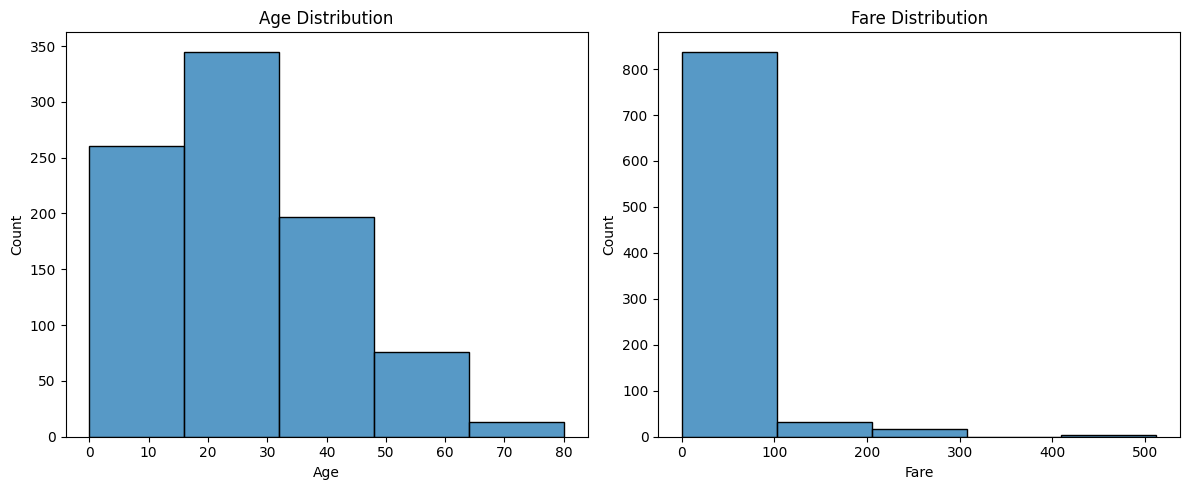

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data["age"], bins=5, ax=axes[0])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

sns.histplot(data["fare"], bins=5, ax=axes[1])
axes[1].set_title("Fare Distribution")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

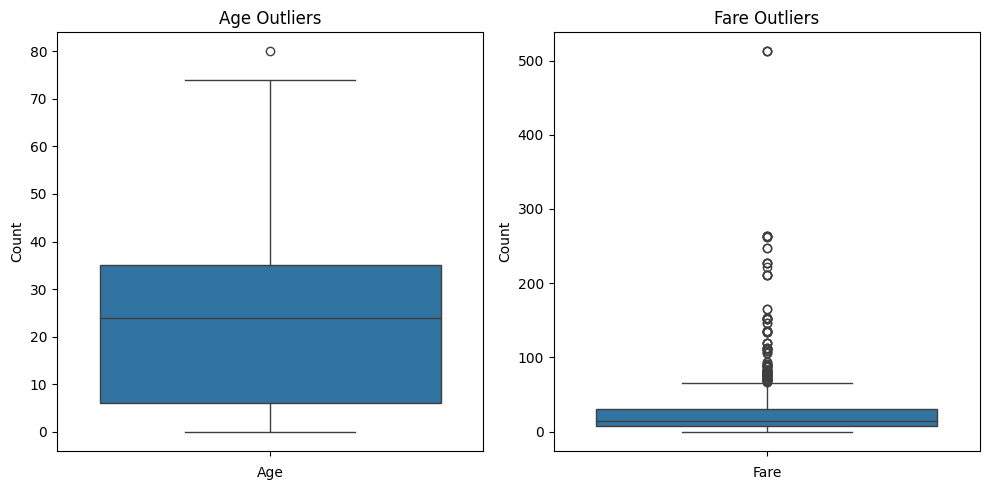

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

sns.boxplot(data["age"], ax=axes[0])
axes[0].set_title("Age Outliers")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

sns.boxplot(data["fare"], ax=axes[1])
axes[1].set_title("Fare Outliers")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [16]:
Q1 = data["fare"].quantile(0.25)
Q3 = data["fare"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data["fare"] < lower_bound) | (data["fare"] > upper_bound)]["fare"]
print(outliers.count())

116


In [17]:
fare_mean = data["fare"].mean()
fare_median = data["fare"].median()
fare_mode = data["fare"].mode()[0]
print("*"*50)
print("Fare_Mean  :", fare_mean)
print("Fare_Median:", fare_median)
print("Fare_Mode  :", fare_mode)
if fare_mean > fare_median > fare_mode:
  print("*"*50)
  print("fare_mean > fare_median > fare_mode")
  print("*"*50)
  print("Distribution is Positively Skewed (Right Skewed)")
elif fare_mean < fare_median < fare_mode:
  print("*"*50)
  print("fare_mean < fare_median < fare_mode")
  print("*"*50)
  print("Distribution is Negatively Skewed (Left Skewed)")
else:
  print("Distribution is approximately Symmetric")

**************************************************
Fare_Mean  : 32.204207968574636
Fare_Median: 14.4542
Fare_Mode  : 8.05
**************************************************
fare_mean > fare_median > fare_mode
**************************************************
Distribution is Positively Skewed (Right Skewed)


# #Bivariate Analysis

In [18]:
male = data[data["sex"] == "male"]
female = data[data["sex"] == "female"]
print("Male survival rate:", male["survived"].mean() * 100)
print("Female survival rate:", female["survived"].mean() * 100)

Male survival rate: 18.890814558058924
Female survival rate: 74.20382165605095


In [19]:
#survival Rate by pclass
for pclass in [1, 2, 3]:
    new_data = data[data["pclass"] == pclass]
    print(
        "Pclass", pclass,
        "survival rate:",
        new_data["survived"].mean() * 100)

Pclass 1 survival rate: 62.96296296296296
Pclass 2 survival rate: 47.28260869565217
Pclass 3 survival rate: 24.236252545824847


In [20]:
for sex in ["male", "female"]:
  for pclass in [1, 2, 3]:
    new_data = data[(data["sex"] == sex) &
            (data["pclass"] == pclass)]
    print(sex,
            "Pclass", pclass,
            "Survival rate:",
            new_data["survived"].mean() * 100)

male Pclass 1 Survival rate: 36.885245901639344
male Pclass 2 Survival rate: 15.74074074074074
male Pclass 3 Survival rate: 13.544668587896252
female Pclass 1 Survival rate: 96.80851063829788
female Pclass 2 Survival rate: 92.10526315789474
female Pclass 3 Survival rate: 50.0


In [21]:
new_data = data[(data["sex"] == "female") &
    (data["pclass"] == 1)]
print("Female OR First Class survival rate:",
      data["survived"].mean() * 100)

Female OR First Class survival rate: 38.38383838383838


In [22]:
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"]
corr = data[corr_columns].corr()
print(corr)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.338481  0.010539 -0.035322  0.081629  0.257307
pclass   -0.338481  1.000000 -0.361353  0.083081  0.018443 -0.549500
age       0.010539 -0.361353  1.000000 -0.184664 -0.048786  0.135516
sibsp    -0.035322  0.083081 -0.184664  1.000000  0.414838  0.159651
parch     0.081629  0.018443 -0.048786  0.414838  1.000000  0.216225
fare      0.257307 -0.549500  0.135516  0.159651  0.216225  1.000000


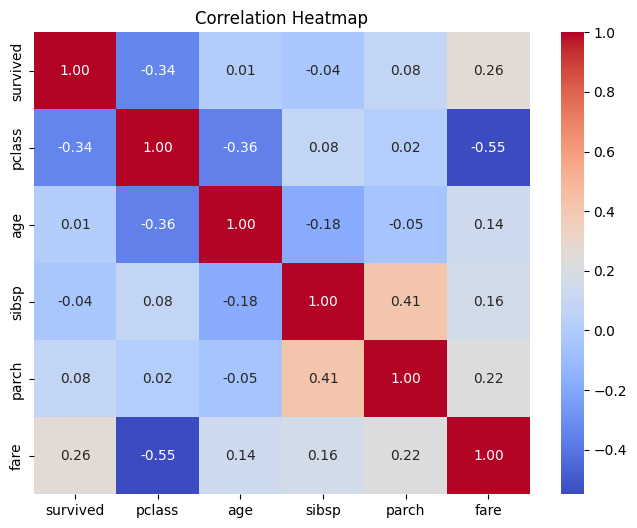

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [24]:
pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):

        col1 = corr.columns[i]
        col2 = corr.columns[j]

        value = corr.iloc[i, j]

        pairs.append(
            (col1, col2, value, abs(value))
        )

pairs = sorted(pairs, key=lambda x: x[3], reverse=True)

print("Two strongest correlations:")

for pair in pairs[:2]:
    print(
        pair[0],
        "and",
        pair[1],
        "correlation =",
        round(pair[2], 3)
    )

Two strongest correlations:
pclass and fare correlation = -0.549
sibsp and parch correlation = 0.415


# **Charts**

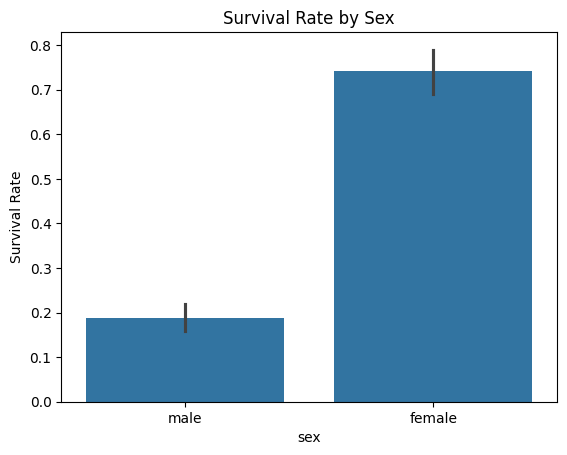

********************************************************************************
INTERPRETATION: The female survival rate is much higher than the male survival rate.
This indicates that sex was strongly associated with survival in the Titanic dataset.


In [25]:
sns.barplot(data=data, x="sex", y="survived")

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()
print("*"*80)
print("INTERPRETATION:","The female survival rate is much higher than the male survival rate.\nThis indicates that sex was strongly associated with survival in the Titanic dataset.")

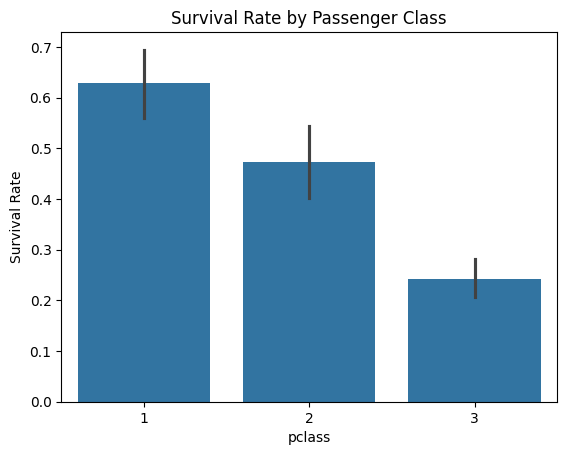

********************************************************************************
INTERPRETATION: Survival rate changes according to the passenger classes,
 first class passengers are survival rate is higher than the passengers in lower class.


In [26]:
sns.barplot(data=data, x="pclass", y="survived")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()
print("*"*80)
print("INTERPRETATION:","Survival rate changes according to the passenger classes,\n first class passengers are survival rate is higher than the passengers in lower class.")

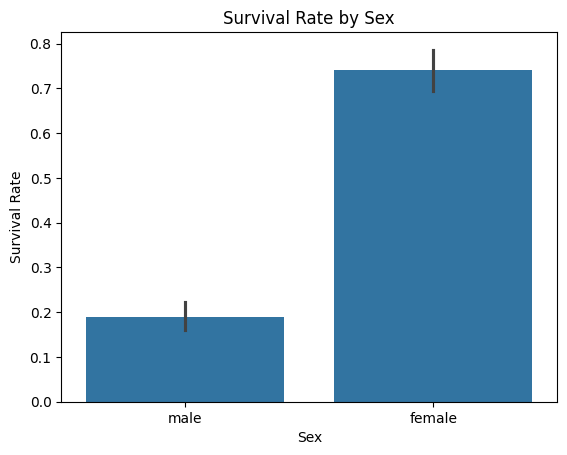

********************************************************************************
INTERPRETATION: The female passengers are higher survial rate than the male passengers.


In [27]:
sns.barplot(data=data, x="sex", y="survived")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()
print("*"*80)
print("INTERPRETATION:","The female passengers are higher survial rate than the male passengers.")

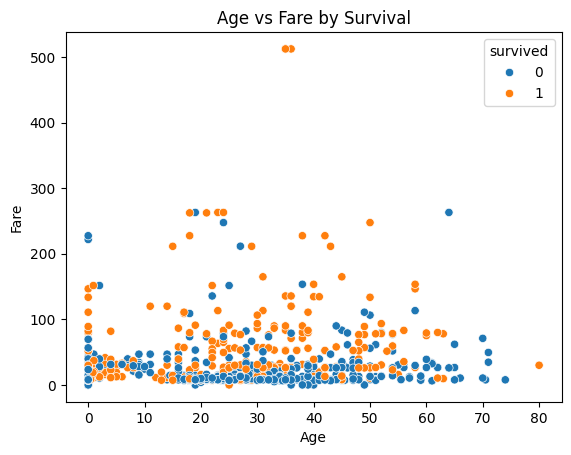

********************************************************************************
INTERPRETATION: The scatter plot shows the relationship between the 
 passenger age and fare while distinguishing survivors from non-survivors.
 It also shows that passengers paid a wide range of fares across different ages.


In [28]:
sns.scatterplot(
    data=data,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()
print("*"*80)
print("INTERPRETATION:","The scatter plot shows the relationship between the \n passenger age and fare while distinguishing survivors from non-survivors.\n It also shows that passengers paid a wide range of fares across different ages.")

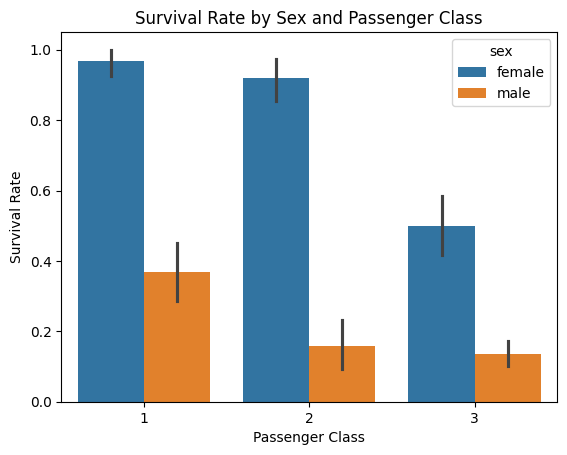

********************************************************************************
INTERPRETATION: This chart compares survival rates using both sex and passenger class.
 It shows that survival was associated with both variables rather than being explained by only one factor


In [29]:
sns.barplot(
    data=data,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()
print("*"*80)
print("INTERPRETATION:","This chart compares survival rates using both sex and passenger class.\n It shows that survival was associated with both variables rather than being explained by only one factor")

# **Before Standerdization**

In [30]:
print("Before standardization")
print("Age mean:", data["age"].mean())
print("Age std:", data["age"].std())
print("Fare mean:", data["fare"].mean())
print("Fare std:", data["fare"].std())

Before standardization
Age mean: 23.79929292929293
Age std: 17.596074065915886
Fare mean: 32.204207968574636
Fare std: 49.693428597180905


In [31]:
#standerdized age and fare
scaler = StandardScaler()
data[["age_z", "fare_z"]] = scaler.fit_transform(
    data[["age", "fare"]])
print("After standardization")
print("Age mean:", data["age_z"].mean())
print("Age std:", data["age_z"].std())
print("Fare mean:", data["fare_z"].mean())
print("Fare std:", data["fare_z"].std())

After standardization
Age mean: 6.778466053828116e-17
Age std: 1.0005616400330468
Fare mean: 3.987332972840069e-18
Fare std: 1.0005616400330462


# **Part-B Model predicting**

In [32]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_z,fare_z
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,no,False,-0.102313,-0.502445
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0.807492,0.786845
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True,0.125138,-0.488854
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0.636903,0.420730
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True,0.636903,-0.486337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,C,Southampton,no,True,0.182001,-0.386671
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,-0.272901,-0.044381
888,0,3,female,0.0,1,2,23.4500,S,Third,woman,False,C,Southampton,no,False,-1.353294,-0.176263
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,0.125138,-0.044381


In [33]:
model_columns = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"]
X = data[model_columns]
y = data["survived"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 7)
y shape: (891,)


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,
    random_state=42,
    stratify=y)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("*"*50)
print("Training class distribution:")
print(y_train.value_counts(normalize=True))
print("*"*50)
print("Testing class distribution:")
print(y_test.value_counts(normalize=True))

Training data: (712, 7)
Testing data: (179, 7)
**************************************************
Training class distribution:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
**************************************************
Testing class distribution:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [35]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"]
categorical_features = [
    "sex",
    "embarked"
]

In [36]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [37]:
logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)

logistic_pred = logistic_pipeline.predict(X_test)
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression completed")

Logistic Regression completed


In [38]:
tree_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

tree_pipeline.fit(X_train, y_train)

tree_pred = tree_pipeline.predict(X_test)
tree_prob = tree_pipeline.predict_proba(X_test)[:, 1]

print("Decision Tree completed")

Decision Tree completed


In [39]:
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest completed")

Random Forest completed


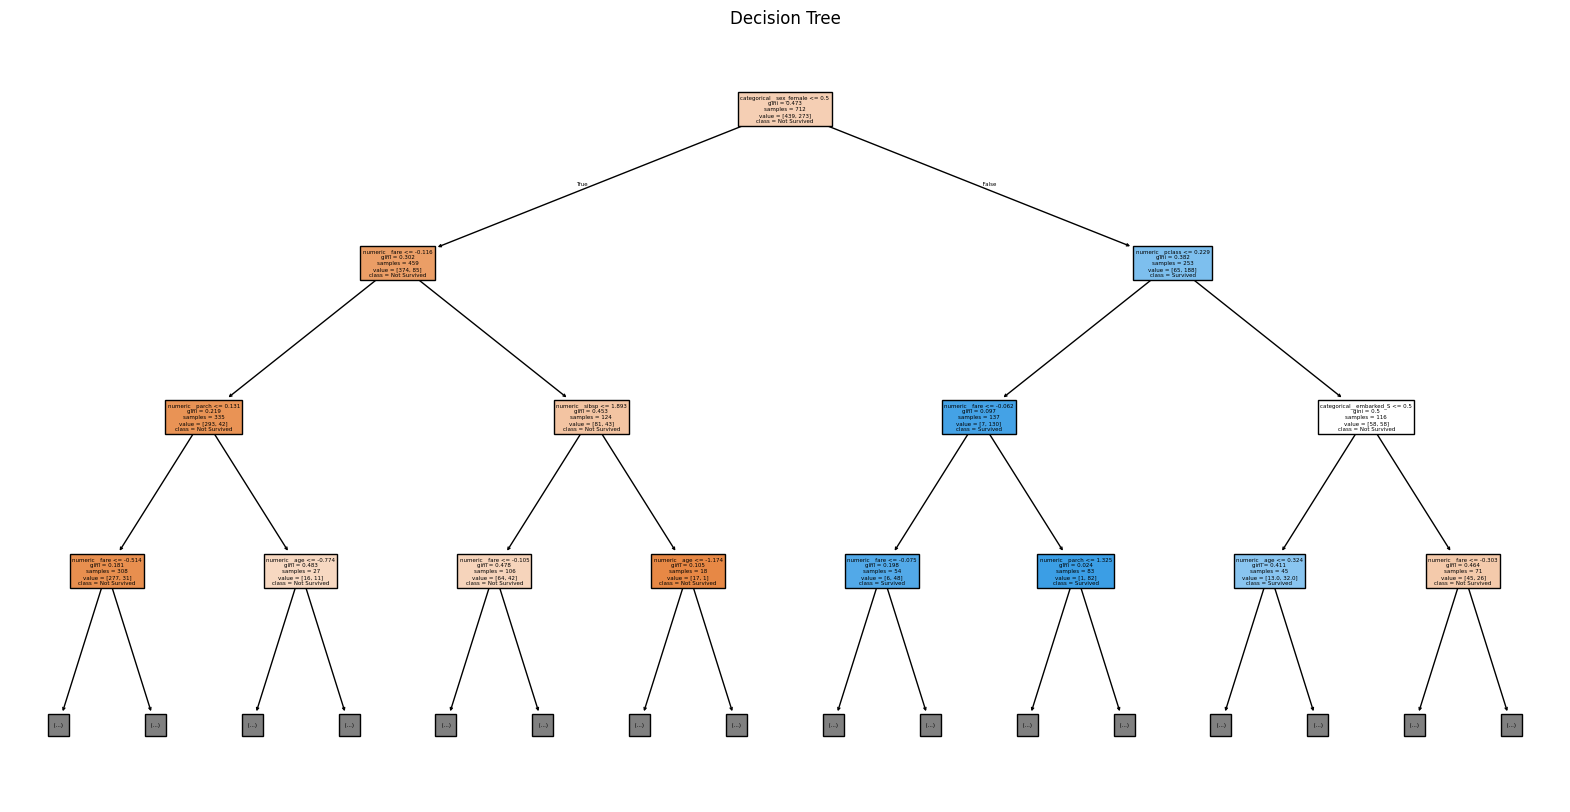

In [40]:
# Get transformed feature names
feature_names = tree_pipeline.named_steps[
    "preprocessing"
].get_feature_names_out()

tree_model = tree_pipeline.named_steps["model"]

plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree")
plt.show()

In [41]:
def get_metrics(y_true, y_pred, y_prob):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    }

In [42]:
results = pd.DataFrame({
    "Logistic Regression": get_metrics(
        y_test, logistic_pred, logistic_prob
    ),

    "Decision Tree": get_metrics(
        y_test, tree_pred, tree_prob
    ),

    "Random Forest": get_metrics(
        y_test, rf_pred, rf_prob
    )
}).T

print(results)

                     Accuracy  Precision    Recall        F1       AUC
Logistic Regression  0.798883   0.779661  0.666667  0.718750  0.837813
Decision Tree        0.826816   0.851852  0.666667  0.747967  0.855731
Random Forest        0.832402   0.819672  0.724638  0.769231  0.828854


****************************************************************************************************

 Logistic Regression
[[97 13]
 [23 46]]


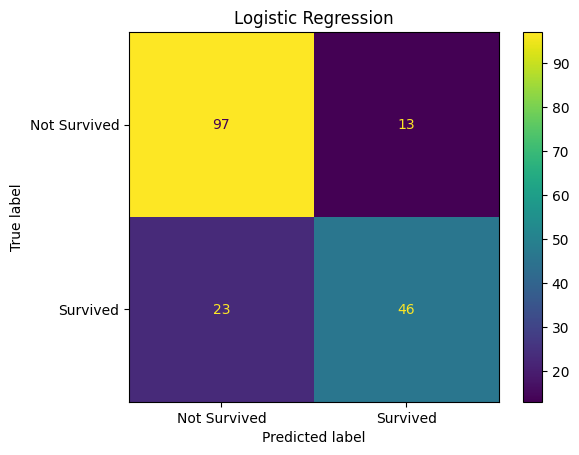

****************************************************************************************************

 Decision Tree
[[102   8]
 [ 23  46]]


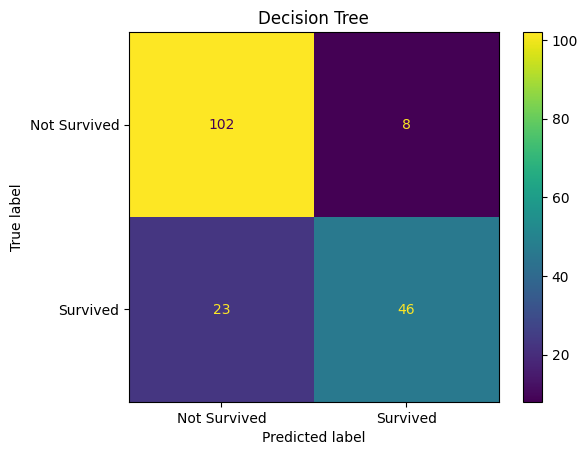

****************************************************************************************************

 Random Forest
[[99 11]
 [19 50]]


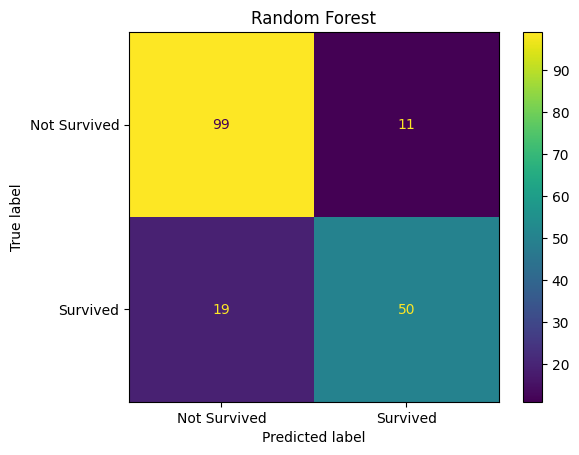

In [43]:
models = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred
}

for name, pred in models.items():

    cm = confusion_matrix(y_test, pred)
    print("*"*100)
    print("\n", name)
    print(cm)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Survived", "Survived"]
    ).plot()

    plt.title(name)
    plt.show()

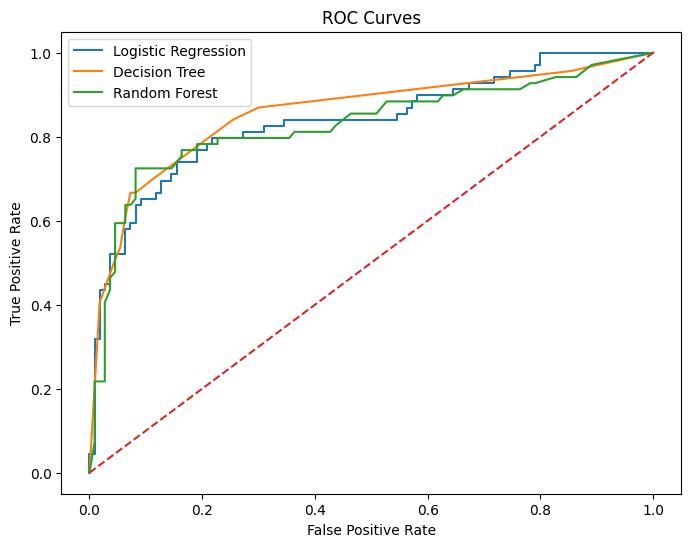

In [44]:
fpr_log, tpr_log, _ = roc_curve(y_test, logistic_prob)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label="Logistic Regression"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label="Decision Tree"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [45]:
print("Class counts:")
print(y.value_counts())
print("\nClass percentages:")
print(y.value_counts(normalize=True) * 100)

Class counts:
survived
0    549
1    342
Name: count, dtype: int64

Class percentages:
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [46]:
baseline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("Baseline")
print("Precision:", precision_score(y_test, baseline_pred))
print("Recall:", recall_score(y_test, baseline_pred))
print("F1:", f1_score(y_test, baseline_pred))

Baseline
Precision: 0.7796610169491526
Recall: 0.6666666666666666
F1: 0.71875


In [47]:
balanced_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

balanced_model.fit(X_train, y_train)

balanced_pred = balanced_model.predict(X_test)

print("Class Weight Balanced")
print("Precision:", precision_score(y_test, balanced_pred))
print("Recall:", recall_score(y_test, balanced_pred))
print("F1:", f1_score(y_test, balanced_pred))

Class Weight Balanced
Precision: 0.7183098591549296
Recall: 0.7391304347826086
F1: 0.7285714285714285


In [48]:
# Transform training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Apply SMOTE ONLY to training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
survived
0    439
1    273
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64


In [49]:
smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

smote_pred = smote_model.predict(X_test_processed)

print("SMOTE")
print("Precision:", precision_score(y_test, smote_pred))
print("Recall:", recall_score(y_test, smote_pred))
print("F1:", f1_score(y_test, smote_pred))

SMOTE
Precision: 0.7464788732394366
Recall: 0.7681159420289855
F1: 0.7571428571428571


In [50]:
imbalance_results = pd.DataFrame({
    "Baseline": [
        precision_score(y_test, baseline_pred),
        recall_score(y_test, baseline_pred),
        f1_score(y_test, baseline_pred)
    ],

    "Class Weight": [
        precision_score(y_test, balanced_pred),
        recall_score(y_test, balanced_pred),
        f1_score(y_test, balanced_pred)
    ],

    "SMOTE": [
        precision_score(y_test, smote_pred),
        recall_score(y_test, smote_pred),
        f1_score(y_test, smote_pred)
    ]
}, index=["Precision", "Recall", "F1"])

print(imbalance_results)

           Baseline  Class Weight     SMOTE
Precision  0.779661      0.718310  0.746479
Recall     0.666667      0.739130  0.768116
F1         0.718750      0.728571  0.757143


In [51]:
rf_oob = RandomForestClassifier(
    random_state=42,
    oob_score=True
)

rf_grid_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", rf_oob)
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    rf_grid_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

best_rf = grid.best_estimator_

print("\nBest Cross Validation Score:")
print(grid.best_score_)

print("\nOOB Score:")
print(best_rf.named_steps["model"].oob_score_)

Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 100}

Best Cross Validation Score:
0.8132965625923372

OOB Score:
0.8132022471910112


In [52]:
reg_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = data[reg_features]
y_reg = data["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print(X_reg_train.shape)
print(X_reg_test.shape)

(712, 6)
(179, 6)


In [53]:
reg_numeric = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical = [
    "sex",
    "embarked"
]

reg_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    ("numeric", reg_numeric_pipeline, reg_numeric),
    ("categorical", reg_categorical_pipeline, reg_categorical)
])

In [54]:
reg_pipeline = Pipeline([
    ("preprocessing", reg_preprocessor),
    ("model", LinearRegression())
])

reg_pipeline.fit(X_reg_train, y_reg_train)

reg_pred = reg_pipeline.predict(X_reg_test)

print("Regression completed")

Regression completed


In [55]:
mae = mean_absolute_error(y_reg_test, reg_pred)

rmse = np.sqrt(mean_squared_error(y_reg_test, reg_pred))

r2 = r2_score(y_reg_test, reg_pred)

n = len(y_reg_test)
p = X_reg_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("MAE        :", mae)
print("RMSE       :", rmse)
print("R²         :", r2)
print("Adjusted R²:", adjusted_r2)

MAE        : 20.89048753278183
RMSE       : 30.564419428859875
R²         : 0.3962996938325183
Adjusted R²: 0.3752403808266759


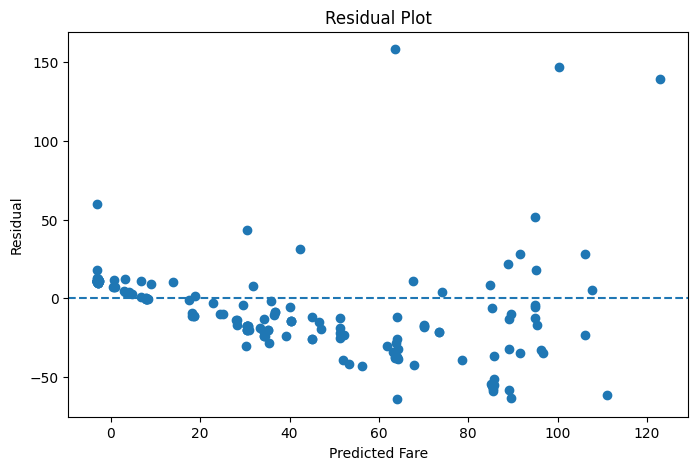

INTERPRETATION: If the residuals are randomly scattered around zero with approximately constant spread, there is no strong evidence of heteroscedasticity.
 If the spread increases or decreases as predicted fare increases, the residual plot indicates heteroscedasticity.
 The plotted residual pattern should be inspected to make the final conclusion.


In [56]:
residuals = y_reg_test - reg_pred

plt.figure(figsize=(8,5))

plt.scatter(reg_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()
print("INTERPRETATION:","If the residuals are randomly scattered around zero with approximately constant spread, there is no strong evidence of heteroscedasticity.\n If the spread increases or decreases as predicted fare increases, the residual plot indicates heteroscedasticity.\n The plotted residual pattern should be inspected to make the final conclusion.")

In [57]:
classification_results = results.copy()

print("===== CLASSIFICATION METRICS =====")
print(classification_results)

print("\n===== REGRESSION METRICS =====")

regression_results = pd.DataFrame({
    "Linear Regression": {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted R2": adjusted_r2
    }
})

print(regression_results)

===== CLASSIFICATION METRICS =====
                     Accuracy  Precision    Recall        F1       AUC
Logistic Regression  0.798883   0.779661  0.666667  0.718750  0.837813
Decision Tree        0.826816   0.851852  0.666667  0.747967  0.855731
Random Forest        0.832402   0.819672  0.724638  0.769231  0.828854

===== REGRESSION METRICS =====
             Linear Regression
MAE                  20.890488
RMSE                 30.564419
R2                    0.396300
Adjusted R2           0.375240


In [58]:
best_classifier = results["F1"].idxmax()

print("Classifier with highest F1:", best_classifier)
print("\nMetrics:")
print(results.loc[best_classifier])

Classifier with highest F1: Random Forest

Metrics:
Accuracy     0.832402
Precision    0.819672
Recall       0.724638
F1           0.769231
AUC          0.828854
Name: Random Forest, dtype: float64


In [59]:
best_params = grid.best_params_

final_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=best_params["model__n_estimators"],
        max_depth=best_params["model__max_depth"],
        max_features=best_params["model__max_features"],
        random_state=42,
        oob_score=True
    ))
])

final_pipeline.fit(X_train, y_train)

print("Final pipeline trained successfully.")

Final pipeline trained successfully.


In [60]:
joblib.dump(
    final_pipeline,
    "/content/titanic_final_pipeline.pkl"
)

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [61]:
loaded_pipeline = joblib.load(
    "/content/titanic_final_pipeline.pkl"
)

# Raw input example
raw_input = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(raw_input)

print("Raw input:")
print(raw_input)

print("\nPrediction:")
print(prediction)

print("\nActual value:")
print(y_test.iloc[0])

Raw input:
     pclass   sex   age  sibsp  parch   fare embarked
565       3  male  24.0      2      0  24.15        S

Prediction:
[0]

Actual value:
0


final verification

In [62]:
import os
print(os.listdir("/content/"))

['.config', 'titanic_final_pipeline.pkl', 'titanic.csv', 'sample_data']


In [63]:
['titanic.csv', 'titanic_final_pipeline.pkl']

['titanic.csv', 'titanic_final_pipeline.pkl']